In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from html import unescape

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../dataset/job_postings.csv")
print(df.head(5))

                                       title            location department  \
0                           Marketing Intern    US, NY, New York  Marketing   
1  Customer Service - Cloud Video Production      NZ, , Auckland    Success   
2    Commissioning Machinery Assistant (CMA)       US, IA, Wever        NaN   
3          Account Executive - Washington DC  US, DC, Washington      Sales   
4                        Bill Review Manager  US, FL, Fort Worth        NaN   

  salary_range                                    company_profile  \
0          NaN  <h3>We're Food52, and we've created a groundbr...   
1          NaN  <h3>90 Seconds, the worlds Cloud Video Product...   
2          NaN  <h3></h3>\r\n<p>Valor Services provides Workfo...   
3          NaN  <p>Our passion for improving quality of life t...   
4          NaN  <p>SpotSource Solutions LLC is a Global Human ...   

                                         description  \
0  <p>Food52, a fast-growing, James Beard Award-w...  

## 1. Data Overview & Basic Profiling

In [ ]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("--- column dtypes ---")
print(df.dtypes)
print(f"\n--- null counts ---")
print(df.isnull().sum())

Shape: 17880 rows x 18 columns

--- Column dtypes ---
title                  object
location               object
department             object
salary_range           object
company_profile        object
description            object
requirements           object
benefits               object
telecommuting          object
has_company_logo       object
has_questions          object
employment_type        object
required_experience    object
required_education     object
industry               object
function               object
fraudulent             object
in_balanced_dataset    object
dtype: object

--- Null counts ---
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                0
requirements            2689
benefits                7196
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience    

- t/f columns should be converted to actual True/False to make downstream analysis cleaner and easier
- "location" is also parsed into country, state, city separately because a composite string will need to be split for geographic patterns to be analysed properly

In [ ]:
# convert t/f columns to boolean
bool_cols = ["telecommuting", "has_company_logo", "has_questions", "fraudulent", "in_balanced_dataset"]
for col in bool_cols:
    df[col] = df[col].map({"t": True, "f": False})

# parse location into country, state, city
location_split = df["location"].str.split(", ", expand=True)
df["country"] = location_split[0]
df["state"] = location_split[1] if 1 in location_split.columns else np.nan
df["city"] = location_split[2] if 2 in location_split.columns else np.nan

# strip leading/trailing whitespace from parsed fields
for col in ["country", "state", "city"]:
    df[col] = df[col].str.strip()
    df[col] = df[col].replace("", np.nan)  # treat empty strings as NaN

print("Boolean columns converted. Location parsed into country / state / city.")
df[["location", "country", "state", "city"]].head(10)

Boolean columns converted. Location parsed into country / state / city.


,location,country,state,city
0,"US, NY, New York",US,NY,New York
1,"NZ, , Auckland",NZ,NaN,Auckland
2,"US, IA, Wever",US,IA,Wever
3,"US, DC, Washington",US,DC,Washington
4,"US, FL, Fort Worth",US,FL,Fort Worth
5,"US, MD,",US,MD,NaN
6,"DE, BE, Berlin",DE,BE,Berlin
7,"US, CA, San Francisco",US,CA,San Francisco
8,"US, FL, Pensacola",US,FL,Pensacola
9,"US, AZ, Phoenix",US,AZ,Phoenix


## 2. Missing Data Analysis
- By visualising missing rates, you can immediately see which fields are sparse. Usually, fraudulent job postings are low-effort as scammers would tend to skip optional fields. Therefore, in this particular dataset, missing data could be one of the most obvious fraud signals. 

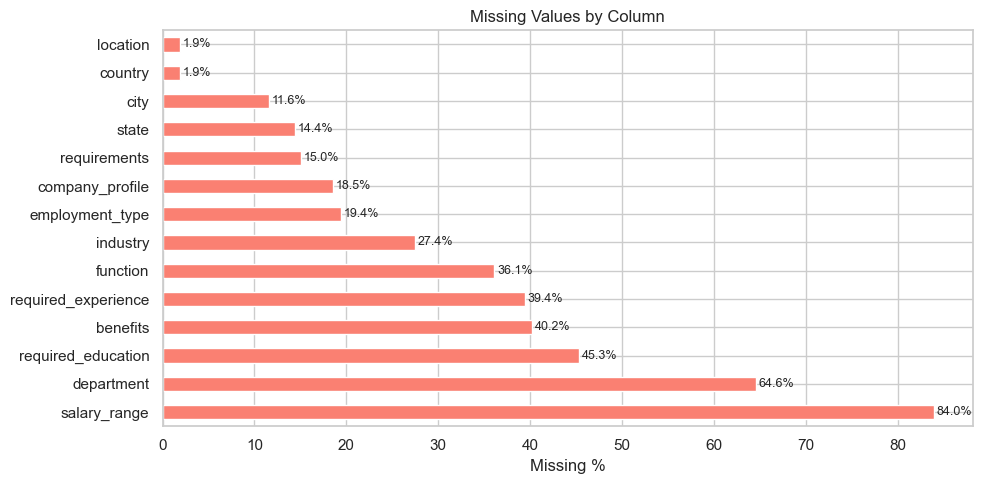

In [ ]:
# overall missing percentages
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, 5))
missing_pct.plot(kind="barh", ax=ax, color="salmon")
ax.set_xlabel("Missing %")
ax.set_title("Missing Values by Column")
for i, v in enumerate(missing_pct):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

By comparing missing rates for fraudulent postings vs legitimate postings, we would be able to see which features would be the most useful for a classifier to determine whether a posting is fraudulent or not. Visualising it side-by-side also makes it easier to see the difference. 
- For instance, in this dataset, fraudulent job postings have a significantly higher number of missing company profiles.

In [ ]:
# compare missing rates: fraudulent vs legitimate
cols_to_check = ["department", "salary_range", "company_profile", "description",
                 "requirements", "benefits", "employment_type", "required_experience",
                 "required_education", "industry", "function"]

fraud_missing = df[df["fraudulent"] == True][cols_to_check].isnull().mean() * 100
legit_missing = df[df["fraudulent"] == False][cols_to_check].isnull().mean() * 100

missing_cmp = pd.DataFrame({"Fraudulent": fraud_missing, "Legitimate": legit_missing})
missing_cmp = missing_cmp.sort_values("Fraudulent", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
missing_cmp.plot(kind="barh", ax=ax, color={"Fraudulent": "salmon", "Legitimate": "steelblue"})
ax.set_xlabel("Missing %")
ax.set_title("Missing Data Rate: Fraudulent vs Legitimate Postings")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("\nKey observation: Fraudulent postings tend to have higher missing rates for company_profile, requirements, and benefits.")

## 3. Class Imbalance
- The dataset is heavily imbalanced where only ~5% of postings are fraudulent. This matters because a model that simply predicts "legitimate" for every posting would still achieve ~95% accuracy while catching zero fraud. So accuracy alone is a misleading metric here; we'd need precision, recall, and F1 instead.
- The "in_balanced_dataset" column flags a pre-curated subset of 900 records (450 fraudulent + 450 legitimate) creating a perfect 50/50 split. This balanced subset can be used for training or evaluation where equal class representation is needed, avoiding the problem of the model being overwhelmed by the majority class.

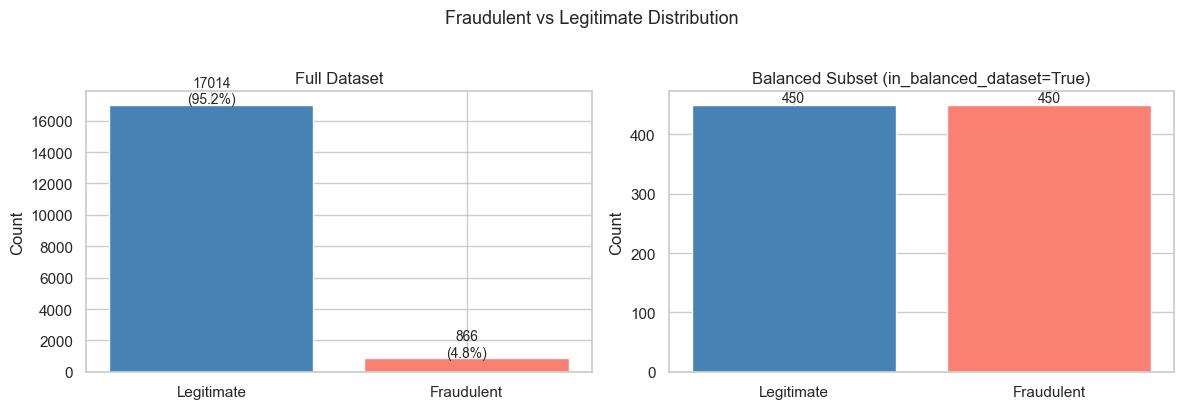

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# full dataset
counts = df["fraudulent"].value_counts()
labels = ["Legitimate", "Fraudulent"]
axes[0].bar(labels, [counts[False], counts[True]], color=["steelblue", "salmon"])
for i, v in enumerate([counts[False], counts[True]]):
    axes[0].text(i, v + 100, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=10)
axes[0].set_title("Full Dataset")
axes[0].set_ylabel("Count")

# balanced subset
balanced = df[df["in_balanced_dataset"] == True]
b_counts = balanced["fraudulent"].value_counts()
axes[1].bar(labels, [b_counts[False], b_counts[True]], color=["steelblue", "salmon"])
for i, v in enumerate([b_counts[False], b_counts[True]]):
    axes[1].text(i, v + 5, str(v), ha="center", fontsize=10)
axes[1].set_title("Balanced Subset (in_balanced_dataset=True)")
axes[1].set_ylabel("Count")

fig.suptitle("Fraudulent vs Legitimate Distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Categorical & Boolean Feature Analysis

boolean features are the simplest cause they're binary (either True or False), and there are no missing values.
- fraud rate --> which category has the highest proportion of fraud?

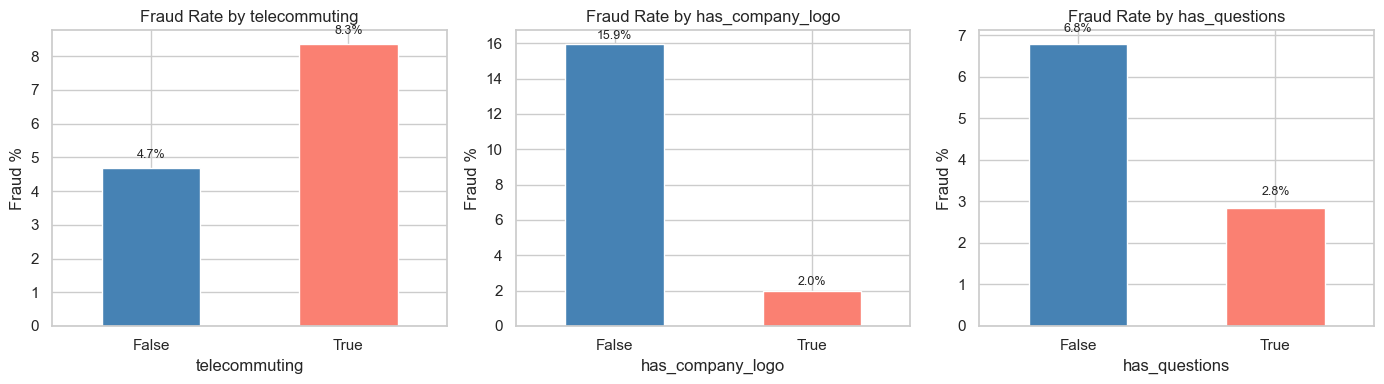

In [11]:
# boolean flags — fraud rate comparison
bool_features = ["telecommuting", "has_company_logo", "has_questions"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(bool_features):
    fraud_rate = df.groupby(col)["fraudulent"].mean() * 100
    fraud_rate.plot(kind="bar", ax=axes[i], color=["steelblue", "salmon"], rot=0)
    axes[i].set_title(f"Fraud Rate by {col}")
    axes[i].set_ylabel("Fraud %")
    axes[i].set_xticklabels(["False", "True"])
    for j, v in enumerate(fraud_rate):
        axes[i].text(j, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

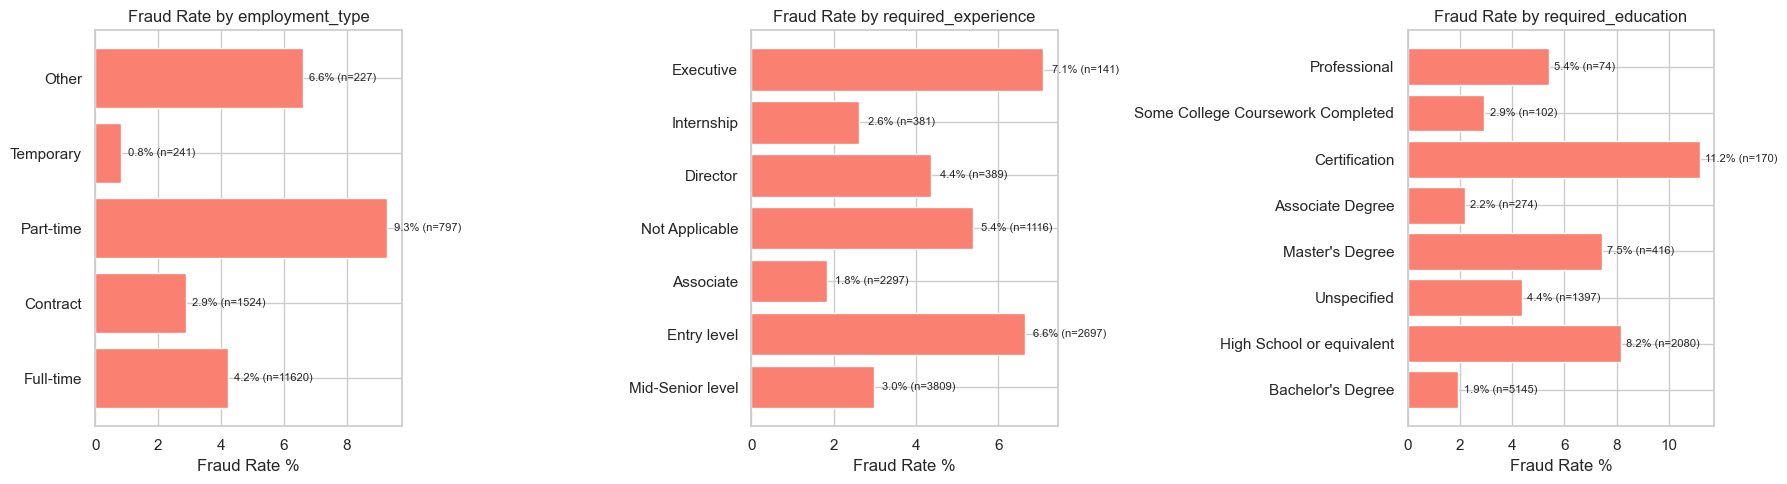

In [12]:
# categorical features — fraud rate per category (top categories only)
cat_features = ["employment_type", "required_experience", "required_education"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_features):
    ct = df.groupby(col).agg(
        total=("fraudulent", "count"),
        fraud_rate=("fraudulent", "mean")
    ).sort_values("total", ascending=False).head(8)
    ct["fraud_rate"] = ct["fraud_rate"] * 100

    bars = axes[i].barh(ct.index, ct["fraud_rate"], color="salmon")
    axes[i].set_xlabel("Fraud Rate %")
    axes[i].set_title(f"Fraud Rate by {col}")
    for j, (rate, total) in enumerate(zip(ct["fraud_rate"], ct["total"])):
        axes[i].text(rate + 0.2, j, f"{rate:.1f}% (n={total})", va="center", fontsize=8)

plt.tight_layout()
plt.show()

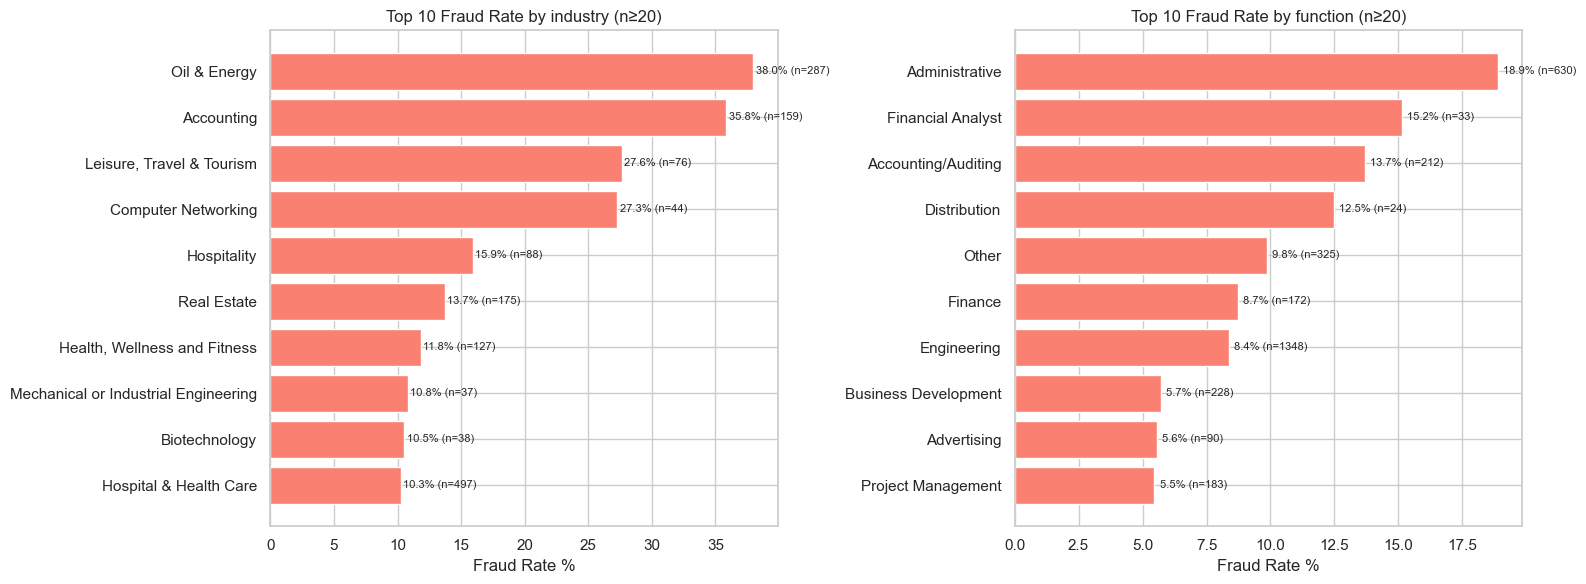

In [13]:
# Industry and Function — top 10 by fraud rate (minimum 20 postings to avoid noise)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, col in enumerate(["industry", "function"]):
    ct = df.groupby(col).agg(
        total=("fraudulent", "count"),
        fraud_rate=("fraudulent", "mean")
    )
    ct = ct[ct["total"] >= 20].sort_values("fraud_rate", ascending=True).tail(10)
    ct["fraud_rate"] = ct["fraud_rate"] * 100

    axes[i].barh(ct.index, ct["fraud_rate"], color="salmon")
    axes[i].set_xlabel("Fraud Rate %")
    axes[i].set_title(f"Top 10 Fraud Rate by {col} (n≥20)")
    for j, (rate, total) in enumerate(zip(ct["fraud_rate"], ct["total"])):
        axes[i].text(rate + 0.2, j, f"{rate:.1f}% (n={total})", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 5. Text Field Analysis
- The dataset's raw text contains HTML tags and entities like &amp, so if you compute the word count based on the raw HTML, you'd be couting these tag names as words which messes up the word count.
- By stripping the HTML tags, we'll be able to get the actual context length and then compare text lengths and quality between fraudulent and legitimate postings.

In [14]:
def strip_html(text):
    """Remove HTML tags and decode entities from a string."""
    if pd.isna(text):
        return np.nan
    text = re.sub(r"<[^>]+>", " ", text)  # remove tags
    text = unescape(text)                  # decode &amp; etc.
    text = re.sub(r"\s+", " ", text).strip()
    return text

text_cols = ["company_profile", "description", "requirements", "benefits"]

for col in text_cols:
    clean_col = f"{col}_clean"
    df[clean_col] = df[col].apply(strip_html)
    df[f"{col}_len"] = df[clean_col].str.len()
    df[f"{col}_words"] = df[clean_col].str.split().str.len()

print("Text fields cleaned. New columns added: *_clean, *_len, *_words")
df[["description_clean", "description_len", "description_words"]].head(3)

Text fields cleaned. New columns added: *_clean, *_len, *_words


,description_clean,description_len,description_words
0,"Food52, a fast-growing, James Beard Award-winn...",908,131
1,Organised - Focused - Vibrant - Awesome! Do yo...,2076,321
2,"Our client, located in Houston, is actively se...",355,50


Why word count > character count?
- Word count is a more meaningful measure of content quality as character count can be inflated by long words or whitespaces.

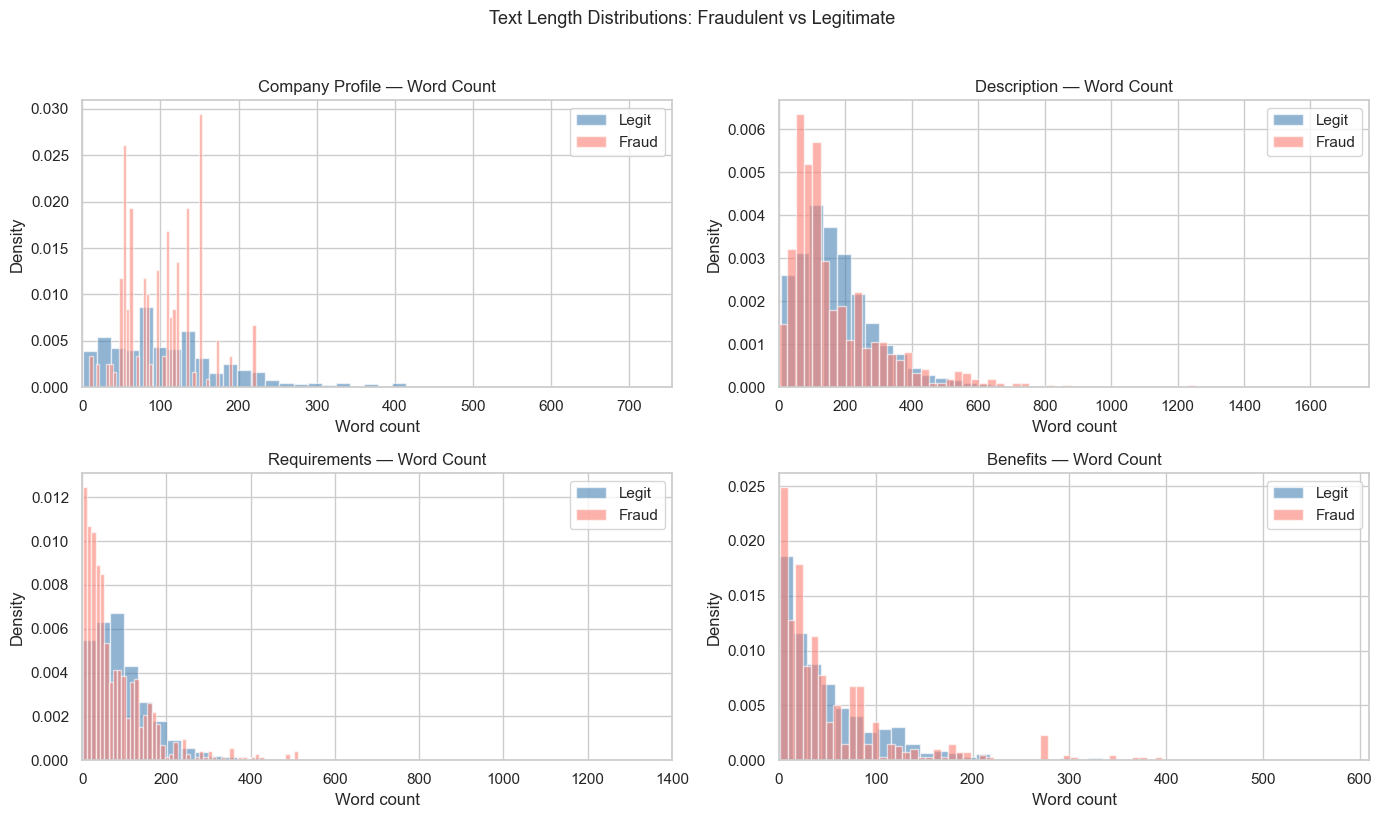

In [23]:
# text length distributions: Fraudulent vs Legitimate
len_cols = [f"{c}_words" for c in text_cols]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flat, len_cols):
    for label, color, name in [(False, "steelblue", "Legit"), (True, "salmon", "Fraud")]:
        subset = df[df["fraudulent"] == label][col].dropna()
        ax.hist(subset, bins=50, alpha=0.6, label=name, color=color, density=True)
    ax.set_title(col.replace("_words", "").replace("_", " ").title() + " — Word Count")
    ax.set_xlabel("Word count")
    ax.set_ylabel("Density")
    ax.legend()
    ax.set_xlim(0, ax.get_xlim()[1] * 0.8)  # trim long tail for readability

plt.suptitle("Text Length Distributions: Fraudulent vs Legitimate", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# median word counts comparison
median_stats = df.groupby("fraudulent")[len_cols].median()
median_stats.index = ["Legitimate", "Fraudulent"]
median_stats.columns = [c.replace("_words", "") for c in median_stats.columns]

print("Median word counts by class:")
print(median_stats.to_string())
print("\nFraudulent job postings consistently have shorter text across all fields.")

Median word counts by class:
            company_profile  description  requirements  benefits
Legitimate             98.0        155.0          83.0      36.0
Fraudulent             98.0        122.0          49.0      32.0

Fraudulent job postings consistently have shorter text across all fields.


## 6. Location Analysis

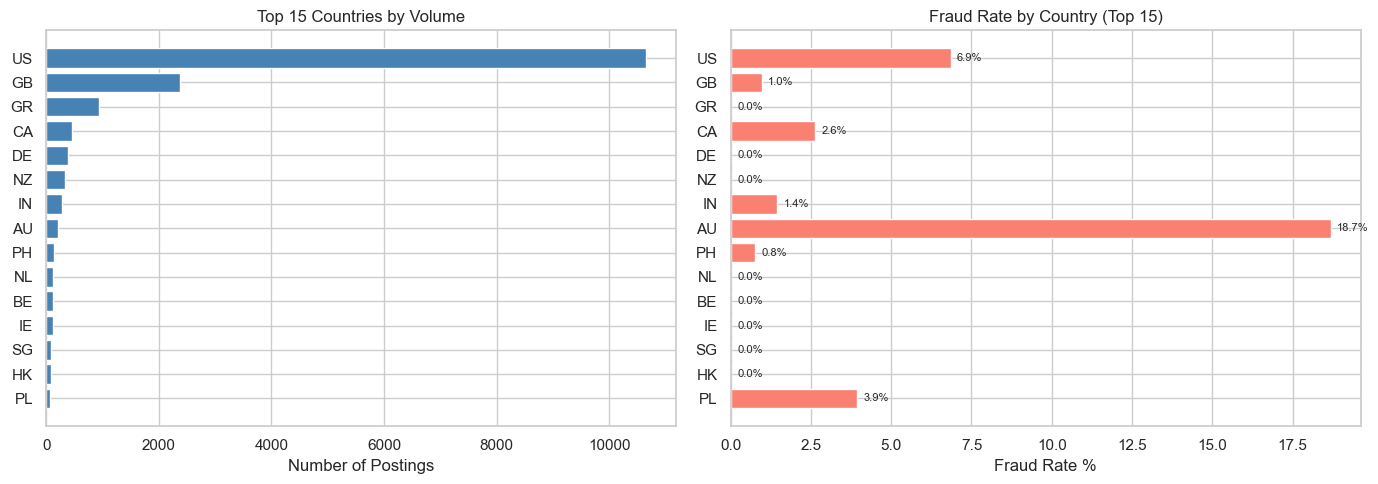

In [18]:
# top 15 countries by posting count and their fraud rates
country_stats = df.groupby("country").agg(
    total=("fraudulent", "count"),
    fraud_rate=("fraudulent", "mean")
).sort_values("total", ascending=False).head(15)
country_stats["fraud_rate"] = country_stats["fraud_rate"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count
axes[0].barh(country_stats.index[::-1], country_stats["total"][::-1], color="steelblue")
axes[0].set_xlabel("Number of Postings")
axes[0].set_title("Top 15 Countries by Volume")

# Fraud rate
axes[1].barh(country_stats.index[::-1], country_stats["fraud_rate"][::-1], color="salmon")
axes[1].set_xlabel("Fraud Rate %")
axes[1].set_title("Fraud Rate by Country (Top 15)")
for i, (rate, total) in enumerate(zip(country_stats["fraud_rate"][::-1], country_stats["total"][::-1])):
    axes[1].text(rate + 0.2, i, f"{rate:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 7. Salary Range Analysis

Postings with salary info: 2868 / 17880 (16.0%)

Legitimate with salary: 15.5%
Fraudulent with salary: 25.8%


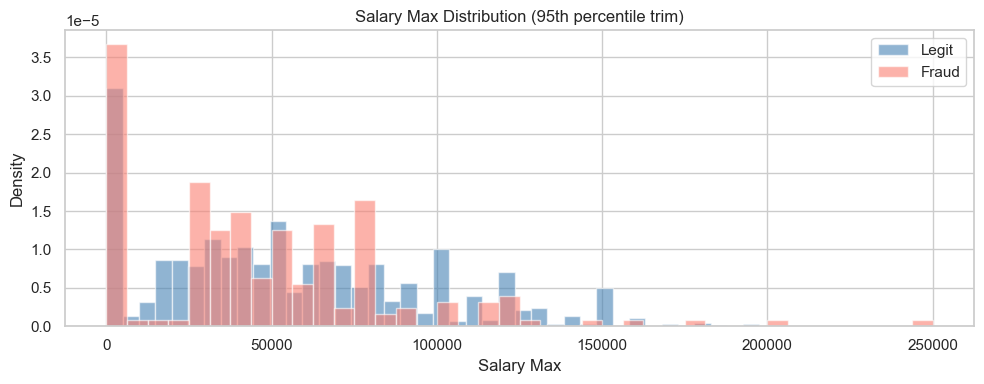

In [ ]:
# parse salary_range into min/max
salary = df["salary_range"].dropna().str.split("-", expand=True)
df["salary_min"] = pd.to_numeric(salary[0], errors="coerce")
df["salary_max"] = pd.to_numeric(salary[1], errors="coerce") if 1 in salary.columns else np.nan

has_salary = df["salary_range"].notna()
print(f"Postings with salary info: {has_salary.sum()} / {len(df)} ({has_salary.mean()*100:.1f}%)")

# salary availability by fraud status
salary_by_fraud = df.groupby("fraudulent")["salary_range"].apply(lambda x: x.notna().mean() * 100)
print(f"\nLegitimate with salary: {salary_by_fraud[False]:.1f}%")
print(f"Fraudulent with salary: {salary_by_fraud[True]:.1f}%")

# distribution of salary_max for those that have it
fig, ax = plt.subplots(figsize=(10, 4))
for label, color in [(False, "steelblue"), (True, "salmon")]:
    subset = df[(df["fraudulent"] == label) & df["salary_max"].notna()]["salary_max"]
    subset = subset[subset < subset.quantile(0.95)]  # trim extreme outliers
    ax.hist(subset, bins=40, alpha=0.6, label="Fraud" if label else "Legit",
            color=color, density=True)
ax.set_title("Salary Max Distribution (95th percentile trim)")
ax.set_xlabel("Salary Max")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Correlation & Summary of Fraud Signals

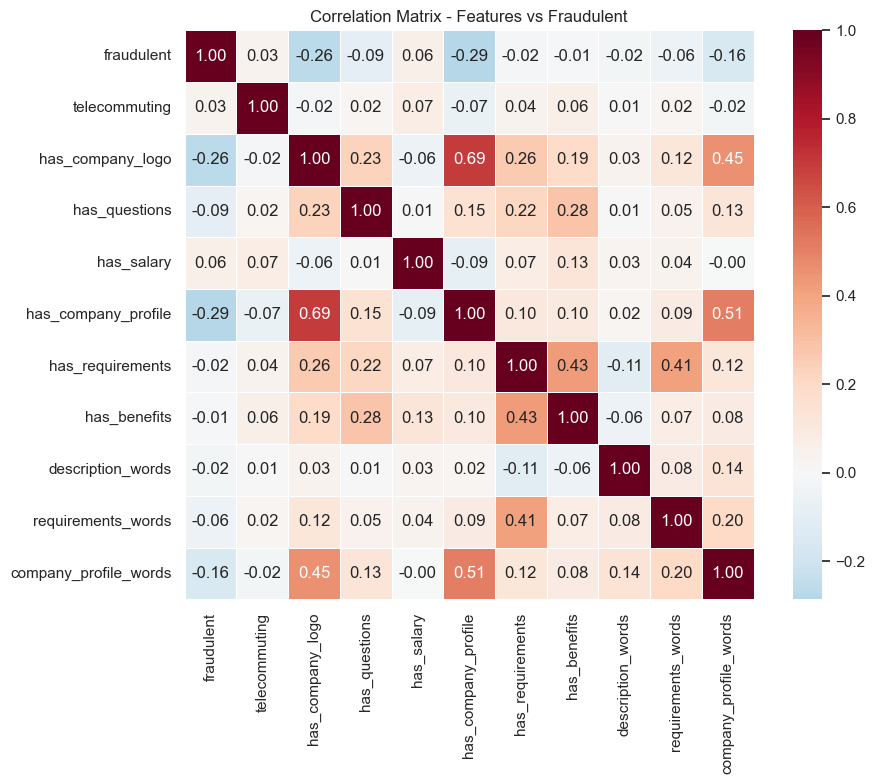

In [25]:
# build a feature matrix of numeric/boolean indicators for correlation
feature_df = pd.DataFrame({
    "fraudulent": df["fraudulent"].astype(int),
    "telecommuting": df["telecommuting"].astype(int),
    "has_company_logo": df["has_company_logo"].astype(int),
    "has_questions": df["has_questions"].astype(int),
    "has_salary": df["salary_range"].notna().astype(int),
    "has_company_profile": df["company_profile"].notna().astype(int),
    "has_requirements": df["requirements"].notna().astype(int),
    "has_benefits": df["benefits"].notna().astype(int),
    "description_words": df["description_words"].fillna(0),
    "requirements_words": df["requirements_words"].fillna(0),
    "company_profile_words": df["company_profile_words"].fillna(0),
})

corr = feature_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title("Correlation Matrix - Features vs Fraudulent")
plt.tight_layout()
plt.show()

In [26]:
# top correlations with fraudulent (sorted by absolute value)
fraud_corr = corr["fraudulent"].drop("fraudulent").sort_values(key=abs, ascending=False)
print("Correlation with 'fraudulent' (sorted by |r|):\n")
for feat, r in fraud_corr.items():
    direction = "+" if r > 0 else "-"
    print(f"  {direction} {feat:30s}  r = {r:+.3f}")

Correlation with 'fraudulent' (sorted by |r|):

  - has_company_profile             r = -0.286
  - has_company_logo                r = -0.262
  - company_profile_words           r = -0.160
  - has_questions                   r = -0.092
  + has_salary                      r = +0.060
  - requirements_words              r = -0.055
  + telecommuting                   r = +0.035
  - description_words               r = -0.021
  - has_requirements                r = -0.017
  - has_benefits                    r = -0.008


## 9. Summary of Key Findings

**Strongest fraud signals (by correlation strength):**

1. **Missing company profile** (r = -0.286) --> the single strongest indicator; fraudulent postings are far more likely to have no company description at all.
2. **Missing company logo** (r = -0.262) --> fraudulent postings are much less likely to include a company logo.
3. **Shorter company profile text** (r = -0.160) --> when a company profile DOES exist, fraudulent postings tend to have shorter ones.
4. **No screening questions** (r = -0.092) --> fraudulent postings are less likely to include application questions.

**Weaker signals:**
- **Salary info slightly more common in fraud** (r = +0.060) --> counterintuitively, fraudulent postings are marginally MORE likely to include salary information. Possibly used as a lure.
- **Shorter requirements text** (r = -0.055) --> fraudulent postings have fewer words in requirements (median 49 vs 83).
- **Telecommuting** (r = +0.035) --> very slightly elevated among fraudulent postings.
- **Missing requirements/benefits** (r = -0.017 / -0.008) --> nearly negligible correlation despite higher missing rates, likely because many legitimate postings also omit these.

**Other observations:**
- The dataset is heavily imbalanced (~95% legitimate, ~5% fraudulent); will need to make use of the "in_balanced_dataset" column when training a model. 
- Text length differences are most pronounced in "requirements" (median 49 vs 83 words). "company_profile" medians are identical (98 vs 98), and "description"/"benefits" differences are modest.